In [ ]:
# transformer nochmal wiederholen und das allgemeine prinzip verstehen

In [1]:
# daten laden und verstehen

import wget, os, gzip, pickle, random, re, sys, importlib, tqdm, math, os, gzip, re, string

from tqdm import trange
from collections import Counter

import torch

import random
from random import choice

IMDB_URL = 'http://dlvu.github.io/data/imdb.{}.pkl.gz'
IMDB_FILE = 'imdb.{}.pkl.gz'
WP_DATA = 'https://codeberg.org/pbm/former/raw/branch/master/data/enwik8.gz'

PAD, START, END, UNK = '.pad', '.start', '.end', '.unk'

SENT = '_s'
TOY = {
    '_s': ['_s _adv', '_np _vp', '_np _vp _prep _np', '_np _vp ( _prep _np )', '_np _vp _con _s','_np _vp ( _con _s )'],
    '_adv': ['briefly', 'quickly', 'impatiently'],
    '_np': ['a _noun', 'the _noun', 'a _adj _noun', 'the _adj _noun'],
    '_prep': ['on', 'with', 'to', 'for', 'at'],
    '_con': ['while', 'but'],
    '_noun': ['mouse', 'bunny', 'cat', 'dog', 'man', 'woman', 'person', 'bear', 'koala', 'judge', 'businessman',
        'businesswoman', 'lawyer', 'teacher', 'engineer'],
    '_vp': ['walked', 'walks', 'ran', 'runs', 'goes', 'went', 'hiked'],
    '_adj': ['short', 'quick', 'busy', 'nice', 'gorgeous', 'spectacular', 'reluctant', 'systematic', 'willowy', 'engaged', 'synthetic']
}

PRINTABLE = set(ord(c) for c in (string.digits + string.ascii_letters + string.punctuation + string.whitespace))

def cas(i):
    """
    Character-as-string. Filters out the ascii codes that aren't safe to print.
    :return:
    """
    assert i >= 0 and i < 256
    return '□' if i not in PRINTABLE else str(chr(i))

def t(blist):
    return torch.tensor([int(b) for b in blist], dtype=torch.uint8)

def gen_sentence(sent=SENT, g=TOY):

    symb = '_[a-z]*'

    while True:

        match = re.search(symb, sent)
        if match is None:
            return sent

        s = match.span()
        sent = sent[:s[0]] + random.choice(g[sent[s[0]:s[1]]]) + sent[s[1]:]

def load_toy(ntrain=100_000, ntest=20_000, to_torch=True, final=False, seed=0):
    """
    Generates language from a toy grammar.
    :param ntrain:
    :param ntest:
    :param to_torch: Whether to return torch tensors (if false, returns python lists)
    :param final: Whether to return the test set or the validation set (True for test)
    :return:
    """

    random.seed(seed)

    train, test = '', ''
    while len(train) < ntrain:
        train += gen_sentence() + ' . '

    random.seed(seed if final else seed + 1)
    # -- change the seed so we get different test/val sets depending on `final`

    while len(test) < ntest:
        test += gen_sentence() + ' . '

    ctr = Counter(train + test)
    i2t = [PAD, START, END, UNK] + [t for t, _ in ctr.most_common()]
    t2i = { w : i for  i, w in enumerate(i2t)}

    train = [t2i[t] for t in train]
    test  = [t2i[t] for t in test]
    
    if to_torch:
        return (t(train), t(test)), (i2t, t2i) # Torch vectors (this takes a few seconds)

    return (train, test), (i2t, t2i)

def load_wp(fname='enwik8.gz', split=(90, 5, 5), to_torch=True, final=False):
    """
    Load the enwik8 dataset from the Hutter challenge as a list or vector of bytes.
    :param fname: Filename for the downloaded data.
    :param split: Percentages for the train/val/test split.
    :param to_torch: Whether to return torch tensors (True) or python lists (False)
    :param final: If False, returns train/val if True returns train/test with the validation
    data added to the training data.
    :return:
    """

    if not os.path.exists(fname):
        # If it doesn't exist, download it
        print('Downloading')
        wget.download(WP_DATA, out=fname)
        
    with gzip.open(fname, 'r') if fname.endswith('.gz') else open(fname, 'rb') as file:

        all = file.read()
        ctr = Counter(all)

        i2t = {token : cas(token) for token, freq in ctr.most_common()}
        t2i = {w : i for i, w in enumerate(i2t)}

        split = tuple(s/sum(split) for s in split)
        split = tuple(int(s * len(all)) for s in split)

        train, val, test = all[:split[0]], all[split[0]:split[0]+split[1]], all[split[0]+split[1]:]

        if final:
            train = train + val
            wh = test
        else:
            wh = val

        if to_torch:
            return (t(train), t(wh)), (i2t, t2i)

        return (train, wh), (i2t, t2i)

def load_xor(ntrain=25_000, ntest=25_000, seed=0):

    random.seed(seed)

    i2w = [PAD, START, END, UNK, 'true', 'false'] #
    w2i = {w : i for i, w in enumerate(i2w)}

    dataset, labels = [], []
    for _ in range(ntrain + ntest):
        sentence = [
            choice((i2w[4], i2w[5])),
            choice((i2w[4], i2w[5]))
        ]

        f1, f2 = (sentence[0] == i2w[4]), (sentence[1] == i2w[4]) # true: very/great false: not/terrible
        # -- these words are the only meaningful features
        label = 0 if f1 != f2 else 1

        dataset.append([w2i[word] for word in sentence])
        labels.append(label)

    return \
        (dataset[:ntrain], labels[:ntrain]), \
        (dataset[ntrain:], labels[ntrain:]), \
        (i2w, w2i), 2

def load_imdb_synth(ntrain=25_000, ntest=25_000, seed=0):
    """
    Synthetic IMDb dataset
    :param seed:
    :param voc:
    :return:
    """

    random.seed(seed)

    adjectives = ['classic', 'silent', 'modern', 'vintage', 'independent', 'foreign', 'animated', 'documentary',
    'epic', 'dramatic', 'romantic', 'comic', 'thrilling', 'mysterious', 'gritty', 'stylized', 'iconic', 'acclaimed',
    'popular', 'forgettable', 'unreleased', 'awardwinning', 'blockbuster', 'lowbudget', 'highbudget', 'experimental',
    'mainstream', 'cult', 'notable', 'original']
    nouns = ['movie', 'film', 'motion-picture', 'feature', 'featurette', 'picture', 'flick', 'cinema', 'screenplay',
    'blockbuster', 'talkie', 'silent', 'biopic', 'short', 'docudrama', 'documentary', 'animation', 'cartoon',
    'anime', 'telefilm', 'miniseries', 'drama', 'comedy', 'thriller', 'western', 'musical', 'noir']
    verbs = ['was', 'is', 'became', 'becomes', 'seemed', 'seems']

    i2w = [PAD, START, END, UNK, 'this', 'not', 'very', 'great','terrible'] + verbs + adjectives + nouns
    w2i = {w : i for i, w in enumerate(i2w)}

    dataset, labels = [], []
    for _ in range(ntrain + ntest):
        sentence = [
            i2w[4], # this
            choice(adjectives), # old
            choice(nouns), # movie
            choice(verbs), # was
            choice((i2w[5], i2w[6])),
            choice((i2w[7], i2w[8]))
        ]

        f1, f2 = (sentence[4] == i2w[6]), (sentence[5] == i2w[7]) # true: very/great false: not/terrible
        # -- these words are the only meaningful features
        label = 0 if f1 != f2 else 1

        dataset.append([w2i[word] for word in sentence])
        labels.append(label)

    return \
        (dataset[:ntrain], labels[:ntrain]), \
        (dataset[ntrain:], labels[ntrain:]), \
        (i2w, w2i), 2

def load_imdb(final=False, val=5000, seed=0, voc=None, char=False):

    cst = 'char' if char else 'word'

    imdb_url = IMDB_URL.format(cst)
    imdb_file = IMDB_FILE.format(cst)

    if not os.path.exists(imdb_file):
        wget.download(imdb_url)

    with gzip.open(imdb_file) as file:
        sequences, labels, i2w, w2i = pickle.load(file)

    if voc is not None and voc < len(i2w):
        nw_sequences = {}

        i2w = i2w[:voc]
        w2i = {w: i for i, w in enumerate(i2w)}

        mx, unk = voc, w2i['.unk']
        for key, seqs in sequences.items():
            nw_sequences[key] = []
            for seq in seqs:
                seq = [s if s < mx else unk for s in seq]
                nw_sequences[key].append(seq)

        sequences = nw_sequences

    if final:
        return (sequences['train'], labels['train']), (sequences['test'], labels['test']), (i2w, w2i), 2

    # Make a validation split
    random.seed(seed)

    x_train, y_train = [], []
    x_val, y_val = [], []

    val_ind = set( random.sample(range(len(sequences['train'])), k=val) )
    for i, (s, l) in enumerate(zip(sequences['train'], labels['train'])):
        if i in val_ind:
            x_val.append(s)
            y_val.append(l)
        else:
            x_train.append(s)
            y_train.append(l)

    return (x_train, y_train), \
           (x_val, y_val), \
           (i2w, w2i), 2

In [4]:
def batchify_rand(x, bsz, T):
    N = x.size(0)
    rand_start_indices = torch.randint(0, N - T + 1, (bsz,)).unsqueeze(1)
    off_sets = torch.arange(T).unsqueeze(0)
    indices = rand_start_indices + off_sets
    batch = x[indices].long()
    return batch

In [4]:
# baseline? simples MLP? model.py
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.distributions as dist
import numpy as np

class MLPLayer(nn.Module):
    def __init__(self, n_input, n_output):
        super().__init__()
        self.W = nn.Parameter(torch.empty(n_input, n_output))
        nn.init.xavier_uniform_(self.W)
        self.b = nn.Parameter(torch.zeros(n_output))

    def forward(self, x):
        # x:(B, n_input)
        # out: (B, n_output)
        return x @ self.W + self.b

class MLP(nn.Module): 
    def __init__(self, vocab_size, emb_dim, n_input, n_hidden, n_output):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, emb_dim)
        self.layer1 = MLPLayer(n_input, n_hidden)
        self.layer2 = MLPLayer(n_hidden, n_hidden)
        self.layer3 = MLPLayer(n_hidden, n_output)
        self.relu = nn.ReLU()

    def forward(self, x):
        # x: (B, T_in)
        x = self.embedding(x)                  # (B, T_in, emb_dim)
        x = x.reshape(x.size(0), -1)           # (B, T_in * emb_dim)

        y = self.layer1(x)      # 16,512
        y = self.relu(y)
        y = self.layer2(y)      
        y = self.relu(y)
        y = self.layer3(y)
        return y

def train_model(model, optimizer, loss_function, train_data, val_data, device,
                epochs, batch_size, seq_len, train_steps_per_epoch, val_steps):
    
    train_loss_history = []
    val_loss_history = []
    val_acc_history = []

    for _ in range(epochs):
        model.train()
        epoch_train_loss = 0.0

        for _ in range(train_steps_per_epoch):
            train_batch = batchify_rand(train_data, batch_size, seq_len)   # (B, seq_len)
            x_train = train_batch[:, :-1].long().to(device)                           # (B, seq_len-1)
            y_train = train_batch[:, -1].long().to(device)                            # (B,)

            optimizer.zero_grad()
            output = model(x_train)                                        # (B, vocab_size)
            loss = loss_function(output, y_train)
            loss.backward()
            optimizer.step()

            epoch_train_loss += loss.item()

        train_loss_history.append(epoch_train_loss / train_steps_per_epoch)

        model.eval()
        epoch_val_loss = 0.0
        correct = 0
        total = 0

        with torch.no_grad():
            for _ in range(val_steps):
                val_batch = batchify_rand(val_data, batch_size, seq_len)   # WICHTIG: val_data
                x_val = val_batch[:, :-1].long().to(device)
                y_val = val_batch[:, -1].long().to(device)

                val_output = model(x_val)
                val_loss = loss_function(val_output, y_val)
                epoch_val_loss += val_loss.item()

                pred = val_output.argmax(dim=1)
                correct += (pred == y_val).sum().item()
                total += y_val.size(0)

        val_loss_history.append(epoch_val_loss / val_steps)
        val_acc_history.append(correct / total)
    
    return train_loss_history, val_loss_history, val_acc_history, model

def evaluate_model(model, loss_function, data, device, batch_size, seq_len, eval_steps):
    model.eval()
    loss_sum = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for _ in range(eval_steps):
            batch = batchify_rand(data, batch_size, seq_len)   # (B, T_in+1)
            x = batch[:, :-1].long().to(device)                           # (B, T_in)
            y = batch[:, -1].long().to(device)                            # (B,)

            output = model(x)                                  # (B, vocab_size)
            loss = loss_function(output, y)
            loss_sum += loss.item()

            pred = output.argmax(dim=1)
            correct += (pred == y).sum().item()
            total += y.size(0)

    avg_loss = loss_sum / eval_steps
    avg_acc = correct / total
    return avg_loss, avg_acc

def sample_logit(output, temperature=1.0):
    """
    output: logits for one example, shape (vocab_size,)
    """
    if temperature == 0.0:
        return output.argmax()

    p = F.softmax(output / temperature, dim=-1)
    cd = dist.Categorical(p)
    return cd.sample()

def sample_sentence(model, i2c, sequence, device, steps=40, temperature=1.0):
    model.eval()
    sequence = sequence.clone().long().to(device)
    char_idx = []

    with torch.no_grad():
        for _ in range(steps):
            x = sequence.unsqueeze(0).long()          # (1, T_in)
            output = model(x)                         # (1, vocab_size)
            next_idx = sample_logit(output[0], temperature)

            char_idx.append(next_idx.item())
            sequence = torch.cat([sequence[1:], next_idx.view(1).long()], dim=0)

    chars = [i2c[idx] for idx in char_idx]
    return "".join(chars)

# ----------------------------
# data
# ----------------------------
(train, test), (i2c, c2i) = load_toy(final=False)

train_data = train[:int(len(train) * 0.9)]
val_data = train[int(len(train) * 0.9):]

vocab_size = len(i2c)

# kleineres Fenster für MLP-Baseline
seq_len = 65                 # gesamtes Fenster inkl. Target
T_in = seq_len - 1            # Inputlänge, weil letztes Zeichen das Target ist
emb_dim = 30
n_input = T_in * emb_dim
n_hidden = 512
n_output = vocab_size

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

model = MLP(vocab_size, emb_dim, n_input, n_hidden, n_output).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
loss_function = nn.CrossEntropyLoss()

train_loss, val_loss, val_acc, model = train_model(
    model,
    optimizer,
    loss_function,
    train_data,
    val_data,
    device,
    epochs=20,
    batch_size=16,
    seq_len=seq_len,
    train_steps_per_epoch=100,
    val_steps=20
)

print(train_loss)
print(val_loss)
print(val_acc)

test_loss, test_acc = evaluate_model(
    model,
    loss_function,
    test,
    device,
    batch_size=16,
    seq_len=seq_len,
    eval_steps=50
)

print("test loss:", test_loss)
print("test acc:", test_acc)

# ----------------------------
# sampling
# ----------------------------
start_idx = np.random.randint(0, len(train) - T_in)
start_sequence = train[start_idx:start_idx + T_in]

sampled_sentence = sample_sentence(model, i2c, start_sequence, device, steps=100, temperature=1.0)
print(sampled_sentence)

cuda
[2.898668897151947, 2.4404176199436187, 2.0965894794464113, 1.8866403484344483, 1.7132695883512497, 1.5881408220529556, 1.3791187834739684, 1.274636744260788, 1.1409082591533661, 1.0410064682364464, 1.005122504234314, 0.92773422062397, 0.8884402650594712, 0.8059432452917099, 0.8291214960813522, 0.7526077653467655, 0.7269415925443172, 0.684949889704585, 0.6268995478749275, 0.6522857220470906]
[2.637014317512512, 2.2451317727565767, 2.040769320726395, 1.774487966299057, 1.568216288089752, 1.457555240392685, 1.2308941289782525, 1.2594618946313858, 1.1487575054168702, 1.0919152826070786, 1.1331247806549072, 0.878245335817337, 0.8940704047679902, 0.9191410571336747, 0.8010499730706215, 0.8175673723220825, 0.6702425703406334, 0.749548026919365, 0.7811690390110015, 0.6644213641062379]
[0.24375, 0.35625, 0.396875, 0.478125, 0.525, 0.584375, 0.615625, 0.61875, 0.61875, 0.659375, 0.634375, 0.696875, 0.68125, 0.71875, 0.734375, 0.709375, 0.7625, 0.765625, 0.734375, 0.784375]
test loss: 0.675

In [9]:
from src.train_baseline import run

train_loss, val_loss, val_acc, model, test_acc, sampled_sentence = run()

cuda
[2.864075293540955, 2.3347179090976713, 2.0903559589385985, 1.8113154685497284, 1.6693937659263611, 1.494252578020096, 1.3386682015657425, 1.274303223490715, 1.1176660323143006, 1.0565184760093689, 1.0238983491063118, 0.9324430653452873, 0.8625119388103485, 0.8162419283390046, 0.780958906263113, 0.7690204794704915, 0.672061076015234, 0.6748065015673638, 0.5957822423428297, 0.6489997620880604]
[2.610387086868286, 2.1310754299163817, 1.921601301431656, 1.8108071327209472, 1.588617742061615, 1.5651469349861145, 1.2471862316131592, 1.293668046593666, 1.135362297296524, 1.0362282365560531, 1.034086360037327, 0.848763820528984, 0.7520496785640717, 0.9060932040214539, 0.8361658215522766, 0.7865858152508736, 0.6842343062162399, 0.6910458311438561, 0.6869275271892548, 0.6035020962357521]
[0.265625, 0.39375, 0.41875, 0.46875, 0.509375, 0.55625, 0.609375, 0.56875, 0.628125, 0.665625, 0.675, 0.725, 0.75625, 0.70625, 0.71875, 0.75, 0.75625, 0.765625, 0.79375, 0.778125]
test loss: 0.71962989151

In [8]:
sampled_sentence = sample_sentence(model, i2c, start_sequence, steps=100, temperature=1.0)
print(sampled_sentence)

ny ) ) . the .eacher bed lawyer . a geggon a on a buse eng ) ( shite bear walks ( on a nice business


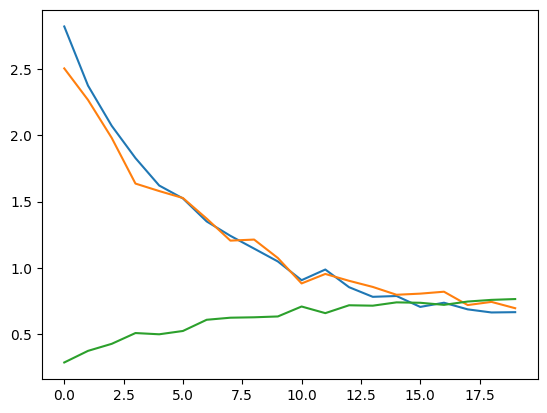

In [7]:
import matplotlib.pyplot as plt

plt.plot(train_loss)
plt.plot(val_loss)
plt.plot(val_acc)

In [3]:
# utils.py

def batchify_rand(x, bsz, L):
  N = x.size(0)
  rand_start_indices = torch.randint(0, (N-L), (bsz,)).unsqueeze(1) # (bsz, 1)
  off_sets = torch.arange(L+1).unsqueeze(0) # (1,L+1)
  indices = rand_start_indices + off_sets # (bsz, 1) + (1,L+1) -> broadcasting
  batch = x[indices].long() # slice out each seq of batch in parallel and conver to int
  return batch

def save_to_json():
  pass



In [2]:
# model.py

import math
import torch
import torch.nn as nn
import torch.nn.functional as F


class MultiHeadSelfAttention(nn.Module):
    def __init__(self, vocab_size, num_heads, max_seq_length, embedding_dim = 300):
        super().__init__()

        # Define the three specific layers
        self.linear_K = nn.Linear(embedding_dim, embedding_dim)
        self.linear_Q = nn.Linear(embedding_dim, embedding_dim)
        self.linear_V = nn.Linear(embedding_dim, embedding_dim)

        self.linear_O = nn.Linear(embedding_dim, embedding_dim)
        
        self.num_heads = num_heads
        self.embedding_dim = embedding_dim


    def forward(self, combined_embed):

        K = self.linear_K(combined_embed) # (B,T,emb)
        Q = self.linear_Q(combined_embed) # (B,T,emb)
        V = self.linear_V(combined_embed) # (B,T,emb)

        hemb = self.embedding_dim // self.num_heads

        K = torch.reshape(K, (K.size(0), K.size(1), self.num_heads, hemb)) # (B,T, k, hemb)
        Q = torch.reshape(Q, (Q.size(0), Q.size(1), self.num_heads, hemb)) # (B,T, k, hemb)
        V = torch.reshape(V, (V.size(0), V.size(1), self.num_heads, hemb)) # (B,T, k, hemb)

        K = K.permute(0,2,1,3) # (B, k, T, hemb)
        Q = Q.permute(0,2,1,3) # (B, k, T, hemb)
        V = V.permute(0,2,1,3) # (B, k, T, hemb)

        K_Q = Q @ K.transpose(-1, -2) # (B, k, T, T)

        K_Q_scaled = K_Q / math.sqrt(hemb) # (B, k, T, T)

        # causal mask so token t cannot attend to future tokens
        T = K_Q_scaled.size(-1)
        mask = torch.triu(
            torch.ones(T, T, device=combined_embed.device, dtype=torch.bool),
            diagonal=1
        ) # (T, T)

        K_Q_scaled = K_Q_scaled.masked_fill(mask, float("-inf")) # (B, k, T, T)

        W = F.softmax(K_Q_scaled, dim=-1) # (B, k, T, T)

        Z = W @ V # (B, k, T, hemb)

        Z = Z.permute(0,2,1,3) # (B, T, k, hemb)

        Z = torch.reshape(Z, (Z.size(0), Z.size(1), self.embedding_dim)) # (B, T, emb)

        O = self.linear_O(Z) # (B, T, emb)

        return O

class TransformerBlock(nn.Module):
    def __init__(self, vocab_size, num_heads, max_seq_length, embedding_dim = 300, dropout = 0.1):
        super().__init__()
        self.selfatt = MultiHeadSelfAttention(vocab_size, num_heads, max_seq_length, embedding_dim)
        self.ln1 = nn.LayerNorm(embedding_dim)
        self.ln2 = nn.LayerNorm(embedding_dim)
        self.ff = nn.Sequential(
            nn.Linear(embedding_dim, 4*embedding_dim),
            nn.ReLU(),
            nn.Linear(4*embedding_dim, embedding_dim)
        )
        self.dropout = nn.Dropout(dropout)

    def forward(self, combined_embed):
        # Sub-layer 1: LN + SelfAtt + DropOut + Resid
        combined_embed_norm = self.ln1(combined_embed)  # (B, T, emb)
        att_out = self.selfatt(combined_embed_norm)     # (B, T, emb)
        att_out = self.dropout(att_out)                 # (B, T, emb)
        residual_added = att_out + combined_embed       # (B, T, emb)

        # Sub-layer 2: LN + FF + DropOut + Resid
        ln_2 = self.ln2(residual_added)                 # (B, T, emb)
        ff_out = self.ff(ln_2)                          # (B, T, emb)
        ff_out = self.dropout(ff_out)                   # (B, T, emb)
        out_resid2 = ff_out + residual_added            # (B, T, emb)

        return out_resid2

class AutoRegressiveTransformer(nn.Module):
    def __init__(self, vocab_size, num_heads, num_Tblocks, max_seq_length, embedding_dim, dropout):
        super().__init__()
        self.blocks = nn.ModuleList([
            TransformerBlock(vocab_size, num_heads, max_seq_length, embedding_dim, dropout)
            for _ in range(num_Tblocks)
        ])
        self.embedding = nn.Embedding(vocab_size, embedding_dim)
        self.pos_embedding = nn.Embedding(max_seq_length, embedding_dim)
        self.Linear = nn.Linear(embedding_dim, vocab_size)
        self.max_seq_length = max_seq_length

    def forward(self, x):
        #Trim sequences that are too long
        if x.size(1) > self.max_seq_length:
            x = x[:, -self.max_seq_length:]

        B, T = x.size()     # B = batch dimension, T = time dimension

        # Input and position embeddings
        input_embeddings = self.embedding(x) # (B, T, emb)
        time_dimension = torch.arange(T, device=x.device) # (T,)
        pos_embeddings = self.pos_embedding(time_dimension) # (T, emb)

        final_embeddings = input_embeddings + pos_embeddings # (B, T, emb) + (T, emb) -> broadcasting

        # Apply transformer blocks
        out = final_embeddings # (B, T, emb)
        for block in self.blocks:
            out = block(out) # (B, T, emb)

        # Linear Layer Classifier
        logits = self.Linear(out) # (B, T, vocab_size)
        return logits

In [ ]:
# utils.py
import yaml

def load_config(path):
    with open(path, "r") as f:
        return yaml.safe_load(f)

def sample_logit(output, temperature=1.0):
    """
    output: logits for one example, shape (vocab_size,)
    """
    if temperature == 0.0:
        return output.argmax()

    p = F.softmax(output / temperature, dim=-1)
    cd = dist.Categorical(p)
    return cd.sample()

def sample_sentence(model, i2c, sequence, device, steps=40, temperature=1.0):
    model.eval()
    sequence = sequence.clone().long().to(device)
    char_idx = []

    with torch.no_grad():
        for _ in range(steps):
            x = sequence.unsqueeze(0).long()          # (1, T)
            output = model(x)                         # (1, T, vocab_size)

            last_logits = output[:, -1, :]            # (1, vocab_size)
            next_idx = sample_logit(last_logits[0], temperature)

            char_idx.append(next_idx.item())
            sequence = torch.cat([sequence[1:], next_idx.view(1).long()], dim=0)

    chars = [i2c[idx] for idx in char_idx]
    return "".join(chars)


# train.py
import sys
from pathlib import Path

sys.path.append(str(Path("..").resolve()))

import argparse
import random
import numpy as np
import torch
import torch.optim as optim
import torch.nn.functional as F
import torch.distributions as dist

#from src.utils import load_config, load_toy, batchify_rand, sample_sentence
#from src.model import AutoRegressiveTransformer


def run_one_experiment(cfg, seed=42):
    
    # ---------------------------------
    # SET UP
    # ---------------------------------
    # set device and seeds
    requested_device = cfg["device"]
    if requested_device == "cuda" and not torch.cuda.is_available():
        device = torch.device("cpu")
    else:
        device = torch.device(requested_device)

    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

    # read in data
    (train, test), (i2c, c2i) = load_toy(final=False)
    train_data = train[:int(len(train) * 0.9)]
    val_data = train[int(len(train) * 0.9):]

    vocab_size = len(i2c)

    # define results object structure
    results = {
        "config": cfg,
        "seed": seed,
        "train_loss": [],
        "val_loss": [],
        "val_acc": [],
        "gradient_norms": [],
        "batch_loss": [],
        "test_loss": None,
        "test_acc": None,
        "best_epoch": None,
        "stopped_early": False,
        "sample_sentence": None
    }

    model = AutoRegressiveTransformer(
        vocab_size,
        cfg["num_heads"],
        cfg["num_Tblocks"],
        cfg["max_sequence_length"],
        cfg["embedding_dim"],
        cfg["dropout"]
    ).to(device)

    optimizer = optim.Adam(model.parameters(), lr=cfg["lr"])

    best_val_loss = float("inf")
    best_epoch = None

    # early stopping setup
    patience = cfg.get("early_stopping_patience", 10)
    min_delta = cfg.get("early_stopping_min_delta", 0.0)
    epochs_without_improvement = 0
    best_model_path = cfg.get("best_model_path", "model_best.pt")

    # ---------------------------------
    # TRAINING
    # ---------------------------------
    for epoch in range(cfg["epochs"]):
        total_loss = 0.0
        num_data_pts_train = 0

        # ---------------------------------
        # TRAINING
        # ---------------------------------
        model.train()
        for batch in range(cfg["n_batches"]):
            # create batch
            train_batch = batchify_rand(train_data, cfg["bsz"], cfg["T"])   # (B, T+1)
            x_train = train_batch[:, :-1].long().to(device)                 # (B, T)
            y_train = train_batch[:, 1:].long().to(device)                  # (B, T)

            optimizer.zero_grad()
            logits = model(x_train)                                         # (B, T, C)
            B, T, C = logits.size()

            logits_flat = logits.reshape(B * T, C)
            targets_flat = y_train.reshape(B * T)

            loss = F.cross_entropy(logits_flat, targets_flat)
            results["batch_loss"].append(loss.item())
            total_loss += loss.item() * targets_flat.size(0)
            num_data_pts_train += targets_flat.size(0)

            loss.backward()

            # compute gradient norms for easier detection of exploding/vanishing gradients
            total_norm = 0.0
            for p in model.parameters():
                if p.grad is not None:
                    param_norm = p.grad.data.norm(2)
                    total_norm += param_norm.item() ** 2
            total_norm = total_norm ** 0.5
            results["gradient_norms"].append(total_norm)

            optimizer.step()

        results["train_loss"].append(total_loss / num_data_pts_train)

        # ---------------------------------
        # VALIDATION
        # ---------------------------------
        model.eval()
        val_losses = []
        num_correct = 0
        num_data_pts_val = 0

        with torch.no_grad():
            for batch in range(cfg["n_batches"] // 4):   # run validation for 1/4 of the training loop amount
                val_batch = batchify_rand(val_data, cfg["bsz"], cfg["T"])   # WICHTIG: val_data
                x_val = val_batch[:, :-1].long().to(device)
                y_val = val_batch[:, 1:].long().to(device)

                # retrieve last logit and target to only compute loss and acc for the last token
                logits = model(x_val)                       # (B, T, C)
                last_logits = logits[:, -1, :]             # (B, C)
                last_targets = y_val[:, -1]                # (B,)

                # compute loss
                loss = F.cross_entropy(last_logits, last_targets)
                val_losses.append(loss.item())

                # retrieve prediction
                preds_last = last_logits.argmax(dim=-1)    # (B,)
                num_correct += (preds_last == last_targets).sum().item()
                num_data_pts_val += last_targets.size(0)

        # compute and store validation loss and accuracy
        avg_val_loss = sum(val_losses) / len(val_losses)
        results["val_loss"].append(avg_val_loss)

        val_acc = num_correct / num_data_pts_val
        results["val_acc"].append(val_acc)

        # early stopping / best model tracking
        if avg_val_loss < best_val_loss - min_delta:
            best_val_loss = avg_val_loss
            best_epoch = epoch + 1
            epochs_without_improvement = 0
            torch.save(model.state_dict(), best_model_path)
        else:
            epochs_without_improvement += 1

        # debug & status per epoch
        print(
            f"Epoch {epoch+1}/{cfg['epochs']} | "
            f"Train Loss: {results['train_loss'][-1]:.4f} | "
            f"Val Last-Token Loss: {avg_val_loss:.4f} | "
            f"Val Accuracy: {val_acc:.4f}"
        )

        if epochs_without_improvement >= patience:
            print(f"Early stopping triggered after epoch {epoch+1}.")
            results["stopped_early"] = True
            break

    results["best_epoch"] = best_epoch

    # load best model before final evaluation
    model.load_state_dict(torch.load(best_model_path, map_location=device))
    model.eval()

    # ---------------------------------
    # RESULTS OUTPUT
    # ---------------------------------
    # output final results after training has finished
    test_losses = []
    num_correct = 0
    num_data_pts_test = 0

    with torch.no_grad():
        for batch in range(cfg["n_batches"] // 4):
            test_batch = batchify_rand(test, cfg["bsz"], cfg["T"])
            x_test = test_batch[:, :-1].long().to(device)
            y_test = test_batch[:, 1:].long().to(device)

            logits = model(x_test)
            last_logits = logits[:, -1, :]
            last_targets = y_test[:, -1]

            loss = F.cross_entropy(last_logits, last_targets)
            test_losses.append(loss.item())

            preds_last = last_logits.argmax(dim=-1)
            num_correct += (preds_last == last_targets).sum().item()
            num_data_pts_test += last_targets.size(0)

    results["test_loss"] = sum(test_losses) / len(test_losses)
    results["test_acc"] = num_correct / num_data_pts_test

    # sample a sentence
    start_idx = np.random.randint(0, len(train) - cfg["T"])
    start_sequence = train[start_idx:start_idx + cfg["T"]].to(device)
    results["sample_sentence"] = sample_sentence(
        model, i2c, start_sequence, device, steps=100, temperature=1.0
    )
    print(f"Final test accuracy is: {results["test_acc"]}")
    print(f"sampled output: {results["sample_sentence"]}")

    # save final/best model to model.pt file so we can reload it later
    torch.save(model.state_dict(), "model.pt")

    return results


# tba later
def run_many_experiments(cfg, seeds):
    results = []
    for seed in seeds:
        result = run_one_experiment(cfg, seed)
        results.append(result)
    return results


def main():
    parser = argparse.ArgumentParser()
    parser.add_argument("--config", default="../configs/default_config.yaml")
    parser.add_argument("--setting", default="single")
    args = parser.parse_args()
    cfg = load_config(args.config)
    
    if args.setting == "single":
        results = run_one_experiment(cfg)
        print(f"Best epoch: {results['best_epoch']}")
        print(f"Test loss: {results['test_loss']:.4f}")
        print(f"Test acc: {results['test_acc']:.4f}")
        print(results["sample_sentence"])
    elif args.setting == "multiple":
        raise NotImplementedError("run_many_experiments not finalized yet.")
    else:
        raise ValueError(f"Unknown setting: {args.setting}")

'''
if __name__ == "__main__":
    main()
'''

'\nif __name__ == "__main__":\n    main()\n'

In [8]:
cfg = load_config("../configs/default_config.yaml")
results = run_one_experiment(cfg)

Epoch 1/2 | Train Loss: 23.1782 | Val Last-Token Loss: 2.2473 | Val Accuracy: 0.3113
Epoch 2/2 | Train Loss: 2.2297 | Val Last-Token Loss: 1.9988 | Val Accuracy: 0.3200
gorusyethe ) then . fonge . ticksittt ather bu agomon wantheswan r gengie thickssthefolyo gatheacthe


In [ ]:
# run experiments

In [ ]:
# run experiments

In [ ]:
# run experiments

### 2.) Wikipedia Dataset

In [ ]:
# load wikipedia data set

'''
This dataset contains 100mb of text from wikipedia (taken from the first Hutter prize)
encoded as a sequence of bytes. That is, we have 256 tokens.
These mostly correspond directly to ASCII characters, but special characters are encoded in
multiple bytes.
Use the same model as in the previous part, but increase the hidden size, the embedding
dimension and possibly the number of layers.
'''